In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [124]:
df=pd.read_csv("global_freelancers_raw.csv")
df.head()

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%


In [125]:
df.shape

(1000, 12)

In [126]:
df.describe()

,age,years_of_experience,rating
count,970.000000,949.000000,899.000000
mean,40.509278,11.340358,2.512570
std,11.942605,9.680610,1.546599
min,20.000000,0.000000,0.000000
25%,31.000000,3.000000,1.400000
50%,41.000000,9.000000,2.600000
75%,51.000000,17.000000,3.800000
max,60.000000,41.000000,5.000000


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    906 non-null    object 
 9   rating               899 non-null    float64
 10  is_active            911 non-null    object 
 11  client_satisfaction  824 non-null    object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB


# Missing Data Cleaning and Type Conversion

In [128]:
df_clean = df.copy()

In [129]:
df_clean["hourly_rate (USD)"].unique()

array(['100', 'USD 100', '50', '$40', '30', '$30', 'USD 75', 'USD 40',
       nan, '$50', '40', '75', 'USD 50', 'USD 30', '$20', '20', '$75',
       '$100', 'USD 20'], dtype=object)

In [130]:
# Prepare Data for Numerical Conversion

df_clean["hourly_rate (USD)"]=df_clean["hourly_rate (USD)"].str.replace("$", "")
df_clean["hourly_rate (USD)"]=df_clean["hourly_rate (USD)"].str.replace("USD ", "")

In [131]:
#  Data Type Conversion

df_clean["hourly_rate (USD)"] = pd.to_numeric(df["hourly_rate (USD)"], errors="coerce")
df_clean["hourly_rate (USD)"].dtype

dtype('float64')

In [132]:
# Filling Missing Values with Skill-Based Median

skill_medians = df_clean.groupby("primary_skill")["hourly_rate (USD)"].median()
df_clean["hourly_rate (USD)"] = df_clean["hourly_rate (USD)"].fillna(df["primary_skill"].map(skill_medians))
df_clean["hourly_rate (USD)"].shape

(1000,)

In [133]:
df_clean["gender"].unique()

array(['f', 'FEMALE', 'male', 'F', 'female', 'm', 'MALE', 'Female', 'M',
       'Male'], dtype=object)

In [134]:
# Standardizing gender Data

df_clean["gender"] = df_clean["gender"].str.lower().str.strip()
df_clean["gender"] = df_clean["gender"].replace({ "f": "female", "m": "male"})

In [135]:
df_clean["gender"].unique()

array(['female', 'male'], dtype=object)

In [136]:
df_clean["is_active"].unique()

array(['0', '1', 'N', 'False', 'True', 'yes', 'Y', nan, 'no'],
      dtype=object)

In [137]:
# Standardizing is_active Data

df_clean["is_active"] = df_clean["is_active"].astype(str).str.lower().str.strip()
df_clean["is_active"] = df_clean["is_active"].replace({    "1": "active",    "true": "active",    "yes": "active",    "y": "active"})
df_clean["is_active"] = df_clean["is_active"].replace({    "0": "inactive",    "false": "inactive",    "no": "inactive",    "n": "inactive"})

In [138]:
df_clean["is_active"].unique()

array(['inactive', 'active', 'nan'], dtype=object)

In [139]:
#  Imputing Missing rating and client_satisfaction Values Based on Primary Skill

In [140]:
df_clean["client_satisfaction"] = df_clean["client_satisfaction"].str.replace('%', '').astype(float)

In [141]:
rating_medians = df_clean.groupby("primary_skill")["rating"].median()
df_clean["rating"] = df_clean["rating"].fillna(df_clean["primary_skill"].map(rating_medians))

In [142]:
satisfaction_medians = df_clean.groupby("primary_skill")["client_satisfaction"].median()
df_clean["client_satisfaction"] = df_clean["client_satisfaction"].fillna(df_clean["primary_skill"].map(satisfaction_medians))

In [158]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    1000 non-null   float64
 9   rating               1000 non-null   float64
 10  is_active            1000 non-null   object 
 11  client_satisfaction  1000 non-null   float64
dtypes: float64(5), object(7)
memory usage: 93.9+ KB


In [159]:
df_clean.describe()

,age,years_of_experience,hourly_rate (USD),rating,client_satisfaction
count,970.000000,949.000000,1000.000000,1000.000000,1000.000000
mean,40.509278,11.340358,48.450000,2.522200,79.297000
std,11.942605,9.680610,19.285212,1.467638,10.454668
min,20.000000,0.000000,20.000000,0.000000,60.000000
25%,31.000000,3.000000,40.000000,1.500000,71.000000
50%,41.000000,9.000000,45.000000,2.600000,79.000000
75%,51.000000,17.000000,50.000000,3.700000,87.000000
max,60.000000,41.000000,100.000000,5.000000,100.000000


# EDA (Exploratory Data Analysis) and Data Visulization

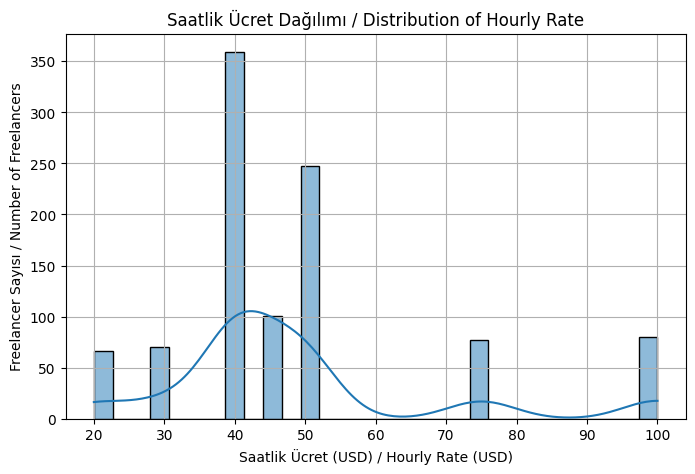

In [143]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["hourly_rate (USD)"], bins=30, kde=True)
plt.title("Saatlik Ücret Dağılımı / Distribution of Hourly Rate")
plt.xlabel("Saatlik Ücret (USD) / Hourly Rate (USD)")
plt.ylabel("Freelancer Sayısı / Number of Freelancers")
plt.grid(True)
plt.show()

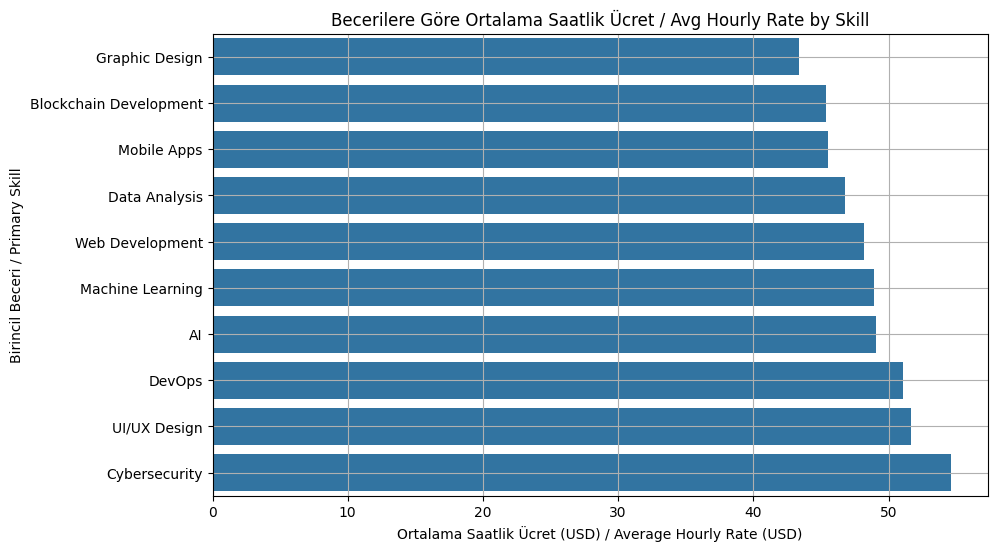

In [144]:
plt.figure(figsize=(10, 6))
avg_rate = df_clean.groupby("primary_skill")["hourly_rate (USD)"].mean().sort_values()
sns.barplot(x=avg_rate.values, y=avg_rate.index)
plt.title("Becerilere Göre Ortalama Saatlik Ücret / Avg Hourly Rate by Skill")
plt.xlabel("Ortalama Saatlik Ücret (USD) / Average Hourly Rate (USD)")
plt.ylabel("Birincil Beceri / Primary Skill")
plt.grid(True)
plt.show()

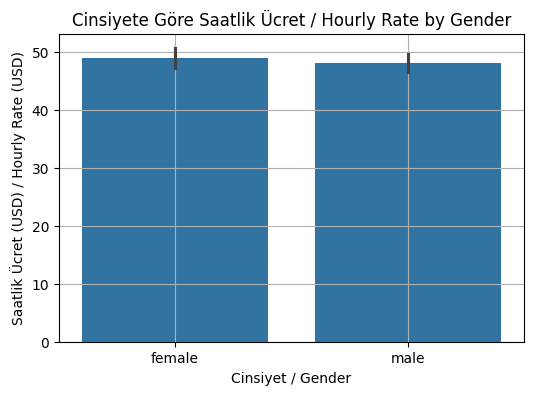

In [146]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df_clean, x="gender", y="hourly_rate (USD)")
plt.title("Cinsiyete Göre Saatlik Ücret / Hourly Rate by Gender")
plt.xlabel("Cinsiyet / Gender")
plt.ylabel("Saatlik Ücret (USD) / Hourly Rate (USD)")
plt.grid(True)
plt.show()

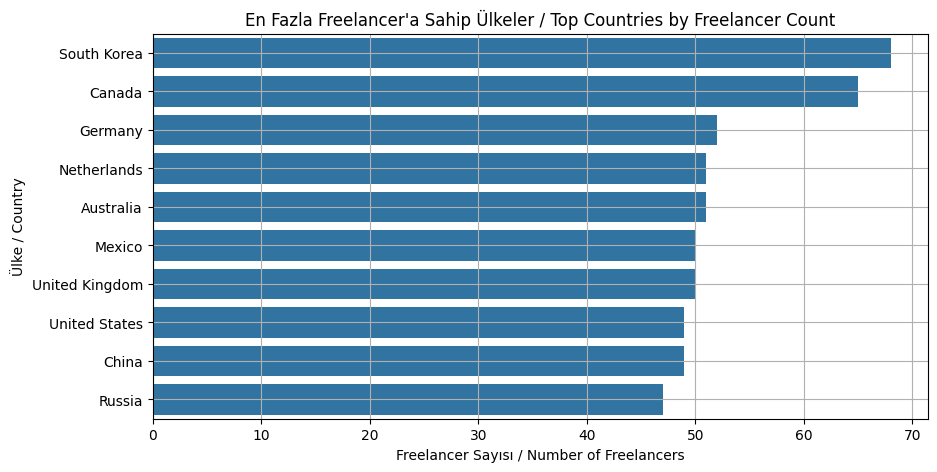

In [148]:
plt.figure(figsize=(10, 5))
top_countries = df_clean["country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("En Fazla Freelancer'a Sahip Ülkeler / Top Countries by Freelancer Count")
plt.xlabel("Freelancer Sayısı / Number of Freelancers")
plt.ylabel("Ülke / Country")
plt.grid(True)
plt.show()

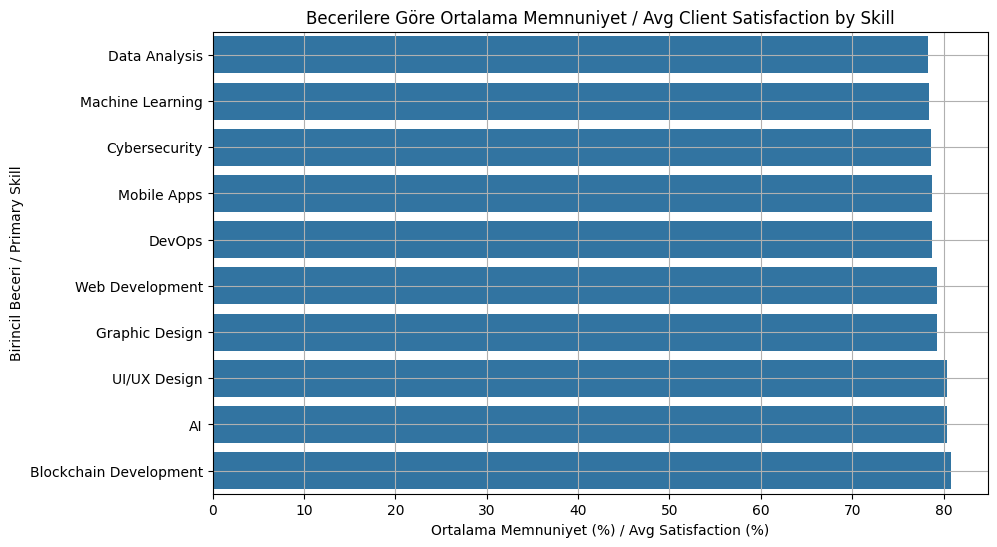

In [150]:
plt.figure(figsize=(10, 6))
avg_satisfaction = df_clean.groupby("primary_skill")["client_satisfaction"].mean().sort_values()
sns.barplot(x=avg_satisfaction.values, y=avg_satisfaction.index)
plt.title("Becerilere Göre Ortalama Memnuniyet / Avg Client Satisfaction by Skill")
plt.xlabel("Ortalama Memnuniyet (%) / Avg Satisfaction (%)")
plt.ylabel("Birincil Beceri / Primary Skill")
plt.grid(True)
plt.show()

In [151]:
turkey_df = df_clean[df_clean["country"] == "Turkey"]

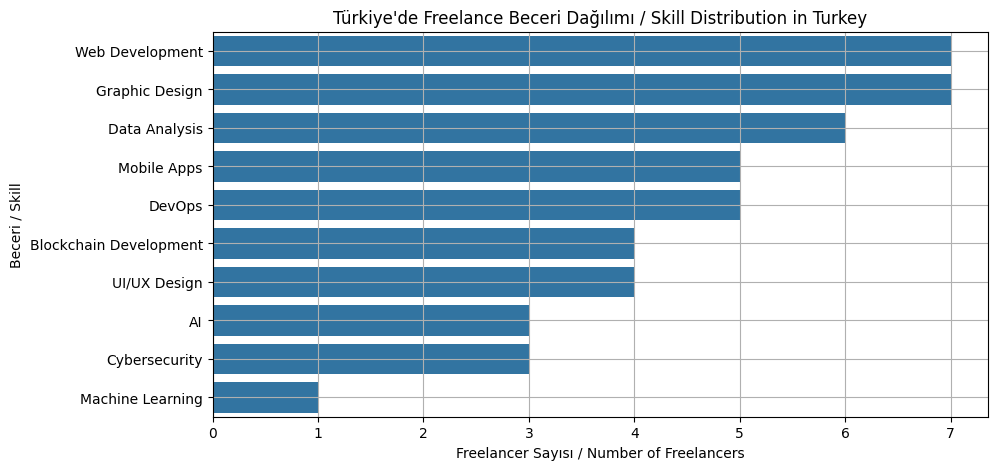

In [152]:
plt.figure(figsize=(10, 5))
turkey_skills = turkey_df["primary_skill"].value_counts()
sns.barplot(x=turkey_skills.values, y=turkey_skills.index)
plt.title("Türkiye'de Freelance Beceri Dağılımı / Skill Distribution in Turkey")
plt.xlabel("Freelancer Sayısı / Number of Freelancers")
plt.ylabel("Beceri / Skill")
plt.grid(True)
plt.show()

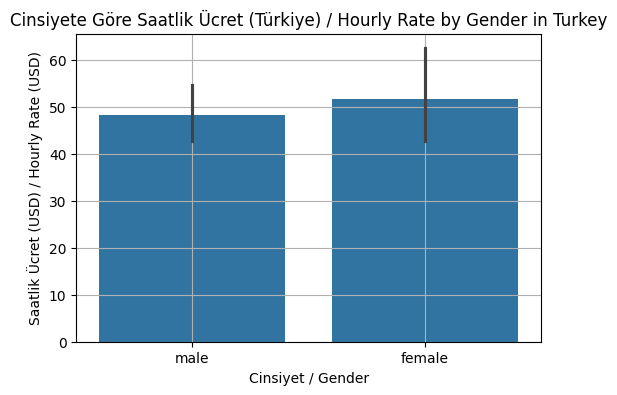

In [157]:
plt.figure(figsize=(6, 4))
sns.barplot(data=turkey_df, x="gender", y="hourly_rate (USD)")
plt.title("Cinsiyete Göre Saatlik Ücret (Türkiye) / Hourly Rate by Gender in Turkey")
plt.xlabel("Cinsiyet / Gender")
plt.ylabel("Saatlik Ücret (USD) / Hourly Rate (USD)")
plt.grid(True)
plt.show()